In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Connect to the same DB file
conn = sqlite3.connect("fruit_sales.db")

**Printing the entire sample table to check its availability.**

In [26]:
full_tb = pd.read_sql_query("SELECT * FROM fruit_sales", conn)
full_tb

,id,product,quantity,price
0,1,Apples,10,2.5
1,2,Bananas,20,1.5
2,3,Oranges,15,3.0
3,4,Grapes,12,4.0
4,5,Mangoes,8,5.0
5,6,Pineapples,6,6.5
6,7,Apples,5,2.5
7,8,Bananas,10,1.5
8,9,Oranges,7,3.0
9,10,Grapes,9,4.0


**An SQL query to sum up the total quantity and total revenue by product and storing in df.**

In [8]:
query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

print("\nTotal sales categorised by fruits:\n")
print(df)


Total sales categorised by fruits:

      product  total_qty  revenue
0      Apples         83    207.5
1     Bananas        130    195.0
2      Grapes         92    368.0
3     Mangoes         67    335.0
4     Oranges        138    414.0
5  Pineapples         41    266.5


**Generating a bar chart on the basis of the above result.**

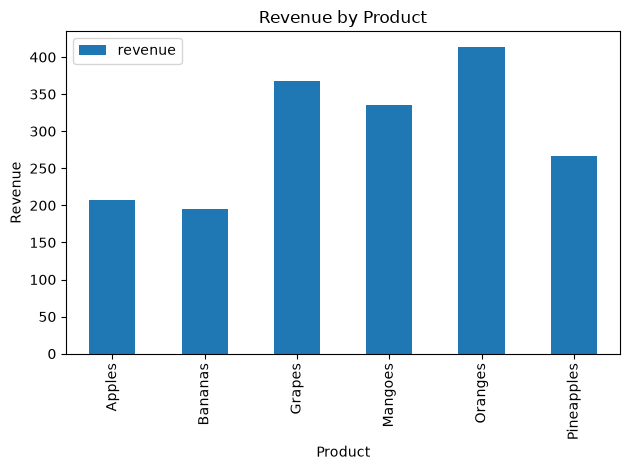

In [24]:
df.plot(kind='bar', x='product', y='revenue') # selecting bar chart and setting product on x axis and revenue on y axis from the the dataframe df
plt.title("Revenue by Product") # title of the graph
plt.ylabel("Revenue") # y axis label
plt.xlabel("Product") # x axis label
plt.tight_layout() # meeded to prevent x axis values from leaving the frame
plt.savefig("sales_chart.png") # saving chart as an image
plt.show() # showing after saving as image to avoid saving plain image

In [29]:
# Closing the connection
conn.close()